# Install and Import necessary libraries

In [1]:
import io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import chi2_contingency, f_oneway, iqr
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    make_scorer,
    average_precision_score
)
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from jaqpotpy import Jaqpot
from jaqpotpy.datasets import JaqpotTabularDataset
from jaqpotpy.models.sklearn import SklearnModel
from jaqpotpy.doa import Leverage, BoundingBox

In [3]:
DATASET = 'cytotoxicity_data'

RANDOM_STATE = 42
NUM_SPLITS = 10

# Upload Cytotoxicity Data and Create DataFrame

In [6]:
# Load Dataset
model = DATASET
df = pd.read_csv(f'{model}.csv')

In [8]:
# Check shape and features of the Dataset
features = df.columns.to_list()
print(f"Original dataset: {df.shape}")
print(f"\nFeature names: \n{features}")

Original dataset: (436, 76)

Feature names: 
['study_id', 'instance', 'monomer_a', 'monomer_b', 'hb_ratio', 'hv_ratio', 'mw', 'mw_units', 'mn', 'mn_units', 'pdi', 'shape', 'shape_grouped', 'thickness', 'units_thickness', 'surface', 'surface_units', 'diameter', 'diameter_units', 'length', 'length_units', 'additive', 'additive1_name', 'additive1_percentage', 'additive1_percentage_units', 'additive1_use', 'additive2_name', 'additive2_percentage', 'additive2_percentage_units', 'additive2_use', 'additive3_name', 'additive3_percentage', 'additive3_percentage_units', 'additive3_use', 'polymer_percentage', 'iso', 'astm', 'assay', 'assay_grouped', 'cell_line', 'cell_line_grouped', 'cell_line_type', 'exposure_type', 'no_cells_per_well', 'inoculum_concentration_units', 'culture_medium', 'culture_medium_grouped', 'dilution_medium', 'dilution_medium_grouped', 'concentration', 'concentration_units', 'dilution', 'sterilization_method', 'incubation_time', 'incubation_time_units', 'incubation_temperatu

Certain Feature Explanation:

- Assay: The experimental method used to measure cytotoxicity.
- Cell line: The specific type of cell used in the experiment.
- Culture medium: The nutrient solution the cells are grown in.
- Number of cells per well: Show how crowded the cells are in the experiment.

In [11]:
# Remove identifiers, units measurements or features with a single value
cols_identifiers_units = ['study_id', 'instance', 'monomer_a', 'monomer_b', 'mw_units', 'mn_units', 'units_thickness', 'surface_units', 'incubation_temperature',
                  'diameter_units', 'length_units', 'additive', 'additive1_name', 'additive2_name', 'additive3_name', 'iso', 'astm',
                  'inoculum_concentration_units', 'concentration_units', 'incubation_time_units', 'incubation_temperature_units',
                  'units_extraction_time', 'units_extraction_t', 'extraction_surface_area_ratio_units', 'growth_constant_μ_units'
                  ]
df = df.drop(columns=cols_identifiers_units)   
print(f"After column removal: {df.shape}")

After column removal: (436, 51)


In [13]:
# Remove cytotoxicity output related columns
cols_leaky = ['cell_viability_percentage','growth_constant_μ', 'rgr',
              'toxicity_grade', 'growth_inhibition_percentage']
df = df.drop(columns=cols_leaky)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (436, 46)


In [15]:
# Remove redundant features
cols_redundant = ['hv_ratio', # hb_ratio + hv_ratio = 100
                  'cell_line_type', # derived from cell_line
                  'additive1_percentage_units',
                  'additive2_percentage_units',
                  'additive3_percentage_units',
                  # 'polymer_percentage' # =100-(additive1+additive2+additive3)percentage, it can be omitted as well
                 ]
df = df.drop(columns=cols_redundant)   
print(f"After cytotoxicity related columns removal: {df.shape}")

After cytotoxicity related columns removal: (436, 41)


In [17]:
df.columns

Index(['hb_ratio', 'mw', 'mn', 'pdi', 'shape', 'shape_grouped', 'thickness',
       'surface', 'diameter', 'length', 'additive1_percentage',
       'additive1_use', 'additive2_percentage', 'additive2_use',
       'additive3_percentage', 'additive3_use', 'polymer_percentage', 'assay',
       'assay_grouped', 'cell_line', 'cell_line_grouped', 'exposure_type',
       'no_cells_per_well', 'culture_medium', 'culture_medium_grouped',
       'dilution_medium', 'dilution_medium_grouped', 'concentration',
       'dilution', 'sterilization_method', 'incubation_time', 'co2_percentage',
       'air', 'extraction_dynamics', 'extraction_time',
       'extraction_temperature', 'extraction_medium',
       'extraction_medium_grouped', 'extraction_surface_area_ratio',
       'number_of_cells_well', 'toxicity'],
      dtype='str')

In [19]:
grouped_pairs = {
    'shape': 'shape_grouped',
    'assay': 'assay_grouped',
    'cell_line': 'cell_line_grouped',
    'culture_medium': 'culture_medium_grouped',
    'dilution_medium': 'dilution_medium_grouped',
    'extraction_medium': 'extraction_medium_grouped',
}

for base_col, grouped_col in grouped_pairs.items():
    if grouped_col in df.columns:
        df[base_col] = df[grouped_col].copy()
        df.drop(columns=[grouped_col], inplace=True)
    else:
        print(f"Skipping missing column: {grouped_col}")

print(df.columns.tolist())

['hb_ratio', 'mw', 'mn', 'pdi', 'shape', 'thickness', 'surface', 'diameter', 'length', 'additive1_percentage', 'additive1_use', 'additive2_percentage', 'additive2_use', 'additive3_percentage', 'additive3_use', 'polymer_percentage', 'assay', 'cell_line', 'exposure_type', 'no_cells_per_well', 'culture_medium', 'dilution_medium', 'concentration', 'dilution', 'sterilization_method', 'incubation_time', 'co2_percentage', 'air', 'extraction_dynamics', 'extraction_time', 'extraction_temperature', 'extraction_medium', 'extraction_surface_area_ratio', 'number_of_cells_well', 'toxicity']


# Train/Test Split

In [22]:
# Set the target feature
target = 'toxicity'

# Split features by their type
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

Numerical features (21):
  - hb_ratio
  - mw
  - mn
  - pdi
  - thickness
  - surface
  - diameter
  - length
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - no_cells_per_well
  - concentration
  - dilution
  - incubation_time
  - co2_percentage
  - extraction_time
  - extraction_temperature
  - extraction_surface_area_ratio
  - number_of_cells_well

Categorical features (13):
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - exposure_type
  - culture_medium
  - dilution_medium
  - sterilization_method
  - air
  - extraction_dynamics
  - extraction_medium


In [24]:
# Drop rows with null values at the target features to be able to make stratified split
df = df[df[target].notna()]

In [26]:
X = df[numerical_cols + categorical_cols].copy()
y = df[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (327, 34) class proportions toxicity
non-toxic    207
toxic        120
Name: count, dtype: int64

Test size (82, 34) class proportions toxicity
non-toxic    52
toxic        30
Name: count, dtype: int64


In [28]:
# Check high missing values on the TRAINING set 
# Missing values overview for all columns in the dataset
missing_df = pd.DataFrame({
    'Missing Values':   X_train.isnull().sum(),
    'Missing Percentage (%)': (X_train.isnull().sum() / len(X_train) * 100).round(1)
}).sort_values('Missing Percentage (%)', ascending=False)

# missing_df.to_excel('missing_values.xlsx', index=True)

print(f"Total rows: {len(X_train)}\n")
missing_df

Total rows: 327



,Missing Values,Missing Percentage (%)
extraction_dynamics,319,97.6
number_of_cells_well,317,96.9
sterilization_method,309,94.5
surface,305,93.3
length,289,88.4
extraction_medium,282,86.2
extraction_temperature,267,81.7
extraction_surface_area_ratio,267,81.7
extraction_time,267,81.7
thickness,256,78.3


In [30]:
# Find columns with high number of missing values in the TRAINING set only
miss_thresh = 0.20  # 20% of the values are missing
high_missing_cols_train = [
    c for c in X_train.columns
    if X_train[c].isnull().sum() / len(X_train) > miss_thresh
    and c != 'concentration' # exclude concentration because it plays an important role in cytotoxicity
]

# Apply same column drop to train and test set
X_train = X_train.drop(columns=high_missing_cols_train)
X_test  = X_test.drop(columns=high_missing_cols_train)

# Drop null rows from train and test set
mask_train = X_train.notna().all(axis=1)
X_train = X_train[mask_train]
y_train = y_train[mask_train]

mask_test = X_test.notna().all(axis=1)
X_test = X_test[mask_test]
y_test = y_test[mask_test]

# Check the new train and test sets
print('Train size', X_train.shape, 'class proportions', pd.Series(y_train).value_counts()) 
print('\nTest size', X_test.shape, 'class proportions', pd.Series(y_test).value_counts())

Train size (123, 16) class proportions toxicity
non-toxic    70
toxic        53
Name: count, dtype: int64

Test size (31, 16) class proportions toxicity
non-toxic    17
toxic        14
Name: count, dtype: int64


# Exploratory Data Analysis (fit on train set, apply on train and test set)

## Examine Numerical Features

In [34]:
for column in X_train.select_dtypes(include=[np.number]).columns.tolist():
    print("\n")
    print(X_train[column].describe())



count    123.000000
mean      92.230894
std        5.702518
min       85.000000
25%       88.000000
50%       90.200000
75%       97.100000
max      100.000000
Name: hb_ratio, dtype: float64


count    123.000000
mean      26.984878
std       17.103533
min        0.000000
25%       12.500000
50%       32.900000
75%       33.330000
max       60.610000
Name: additive1_percentage, dtype: float64


count    123.000000
mean      15.212683
std       15.427955
min        0.000000
25%        0.000000
50%        9.090000
75%       32.900000
max       33.330000
Name: additive2_percentage, dtype: float64


count    123.000000
mean       3.045854
std        6.504017
min        0.000000
25%        0.000000
50%        0.000000
75%        1.320000
max       20.980000
Name: additive3_percentage, dtype: float64


count    123.000000
mean      54.755285
std       30.842972
min       13.990000
25%       32.900000
50%       33.330000
75%       87.500000
max      100.000000
Name: polymer_percentage, dtyp

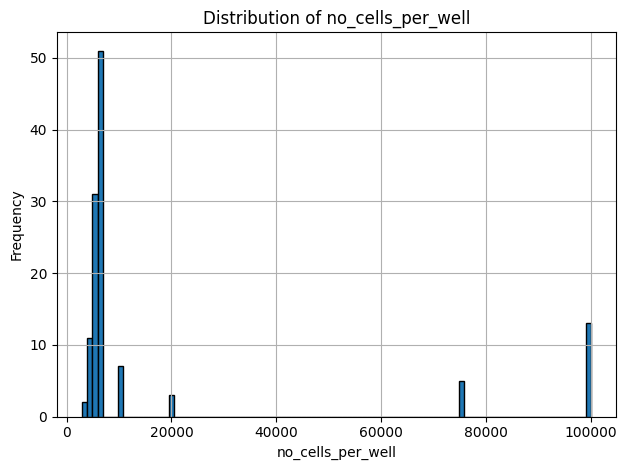



no_cells_per_well
3000.0       2
4000.0      11
5000.0      27
5280.0       4
6000.0      51
10000.0      7
20000.0      3
75000.0      5
100000.0    13
Name: count, dtype: int64


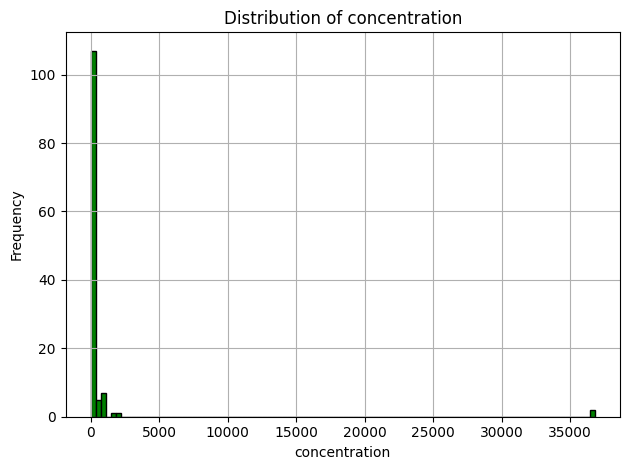



concentration
0.00        10
0.20         8
0.25         4
0.50         4
0.60         7
0.75         4
1.00         5
1.25         3
1.30         9
3.00         9
6.00         8
10.00        2
15.60        3
25.00        4
50.00        4
62.50        2
69.00        5
75.00        1
100.00       9
150.00       1
250.00       4
300.00       1
500.00       4
600.00       1
819.00       3
1000.00      4
1500.00      1
2000.00      1
36800.00     2
Name: count, dtype: int64


In [36]:
# Check heavily skewed features (high value of std)

## Plot a histogram of the distribution of no_cells_per_well
X_train['no_cells_per_well'].hist(bins=100, edgecolor='black')
plt.xlabel('no_cells_per_well')
plt.ylabel('Frequency')
plt.title('Distribution of no_cells_per_well')
plt.tight_layout()
# plt.savefig('no_cells_per_well_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
## Check to decide boundaries of no_cells_per_well
print('\n')
print(X_train['no_cells_per_well'].value_counts().sort_index())

## Plot a histogram of the distribution of concentration
X_train['concentration'].hist(bins=100, edgecolor='black', color='green')
plt.xlabel('concentration')
plt.ylabel('Frequency')
plt.title('Distribution of concentration')
plt.tight_layout()
# plt.savefig('concentration_distribution.png', dpi=600, bbox_inches='tight')
plt.show()
## Check to decide boundaries of concentration
print('\n')
print(X_train['concentration'].value_counts().sort_index())

Features 'no_cells_per_well' and 'concentration' will be converded to categorical features because:

- the features are conceptually ordinal/categorical
- their distribution is heavily multimodal (clusters in to clear groups)

In [38]:
# Categorise no_cells_per_wel feature
bins = [0, 10_000, 50_000, float('inf')]
labels = ['low', 'medium', 'high']

X_train['no_cells_per_well'] = pd.cut(X_train['no_cells_per_well'], bins=bins, labels=labels)
X_test['no_cells_per_well']  = pd.cut(X_test['no_cells_per_well'],  bins=bins, labels=labels)

# Check the categories frequency
print(f"Train set: {X_train['no_cells_per_well'].value_counts()}")
print(f"Test set: {X_test['no_cells_per_well'].value_counts()}")

Train set: no_cells_per_well
low       102
high       18
medium      3
Name: count, dtype: int64
Test set: no_cells_per_well
low       27
high       3
medium     1
Name: count, dtype: int64


In [41]:
# Categorise concetration
bins = [float('-inf'), 0, 2.50, 6.00, 62.50, 250.00, float('inf')]
labels = ['zero', 'very_low', 'low', 'medium', 'high', 'very_high']

X_train['concentration'] = pd.cut(X_train['concentration'], bins=bins, labels=labels)
X_test['concentration']  = pd.cut(X_test['concentration'],  bins=bins, labels=labels)

# Check the categories frequency
print(f"Train set: {X_train['concentration'].value_counts()}")
print(f"\nTest set: {X_test['concentration'].value_counts()}")

Train set: concentration
very_low     44
high         20
low          17
very_high    17
medium       15
zero         10
Name: count, dtype: int64

Test set: concentration
very_low     14
low           7
very_high     4
high          3
zero          2
medium        1
Name: count, dtype: int64


## Outlier Detection

In [44]:
apply_outlier_detection = False  # Set to False to skip

if apply_outlier_detection:
    data = X_train.select_dtypes(include=[np.number])
    outlier_mask = pd.DataFrame(False, index=X_train.index, columns=data.columns)

    for col in data.columns:
        Q1 = np.percentile(data[col], 25)
        Q3 = np.percentile(data[col], 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_mask[col] = (data[col] < lower) | (data[col] > upper)

    outlier_rows = outlier_mask.any(axis=1)
    X_train_clean = X_train[~outlier_rows]
    y_train_clean = y_train[~outlier_rows]

    print(f"Removed {outlier_rows.sum()} outlier rows. Remaining: {len(X_train_clean)}")
else:
    X_train_clean = X_train.copy()
    y_train_clean = y_train.copy()
    print("Outlier detection skipped.")

Outlier detection skipped.


In [46]:
# Check the new categories
for col in X_train.select_dtypes(include=[object]).columns.tolist():
    print("\n")
    print(X_train_clean[col].value_counts())

C:\Users\leoni\AppData\Local\Temp\ipykernel_7484\3441880661.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_train.select_dtypes(include=[object]).columns.tolist():




shape
particulate    93
planar_bulk    19
fibrous        11
Name: count, dtype: int64


additive1_use
functional_or_targeting     78
therapeutic_agent           16
formulation_aid             11
structural_or_mechanical     9
not_applicable               9
Name: count, dtype: int64


additive2_use
stabilizer        51
not_applicable    48
antibiotic        19
activator          5
Name: count, dtype: int64


additive3_use
not_applicable    78
active_drug       26
ceramic_filler    19
Name: count, dtype: int64


assay
metabolic_activity    104
other_endpoint         13
membrane_integrity      5
not_reported            1
Name: count, dtype: int64


cell_line
epithelial_cancer    70
other_or_primary     30
fibroblast           13
immune               10
Name: count, dtype: int64


exposure_type
direct_contact      96
indirect_contact    27
Name: count, dtype: int64


culture_medium
dmem            80
mem_family      22
rpmi_or_hams    21
Name: count, dtype: int64


In [48]:
X_train_clean = X_train_clean.reset_index(drop=True)
X_test_clean  = X_test.reset_index(drop=True)

y_train_clean = y_train_clean.reset_index(drop=True)
y_test_clean  = y_test.reset_index(drop=True)

assert len(X_train_clean) == len(y_train_clean)
assert len(X_test_clean) == len(y_test_clean)

print(f"Train: {len(X_train_clean)} rows | Test: {len(X_test_clean)} rows")

Train: 123 rows | Test: 31 rows


# Feature Selection 

In [51]:
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols

Numerical features (6):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - incubation_time

Categorical features (10):
  - no_cells_per_well
  - concentration
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - exposure_type
  - culture_medium


## Mutual Information 

In [54]:
# Check mutual information between features and target  (numerical and categorical features(ordinal encoded))
# Ordinal encode categorical features for mutual information calculation
ordinal_encoder = OrdinalEncoder()
X_train_encoded = X_train_clean.copy()
X_train_encoded[features_cat] = ordinal_encoder.fit_transform(X_train_encoded[features_cat])    
mi_scores = mutual_info_classif(X_train_encoded, y_train_clean, discrete_features=[X_train_encoded.columns.get_loc(c) for c in features_cat], random_state=10)
mi_scores_series = pd.Series(mi_scores, index=X_train_encoded.columns).sort_values(ascending=False)
print("Mutual Information Scores:")
print(mi_scores_series)
# mi_scores_series.to_excel('../data/mi_scores_cytotoxicity.xlsx')

Mutual Information Scores:
polymer_percentage      0.340286
additive1_percentage    0.332960
additive2_percentage    0.237223
additive3_use           0.166694
additive3_percentage    0.164326
culture_medium          0.124268
hb_ratio                0.121829
concentration           0.121316
additive2_use           0.110757
shape                   0.101951
cell_line               0.083056
assay                   0.053123
additive1_use           0.035459
exposure_type           0.026465
no_cells_per_well       0.023259
incubation_time         0.000000
dtype: float64


## Kendal correlation (Num vs Num)

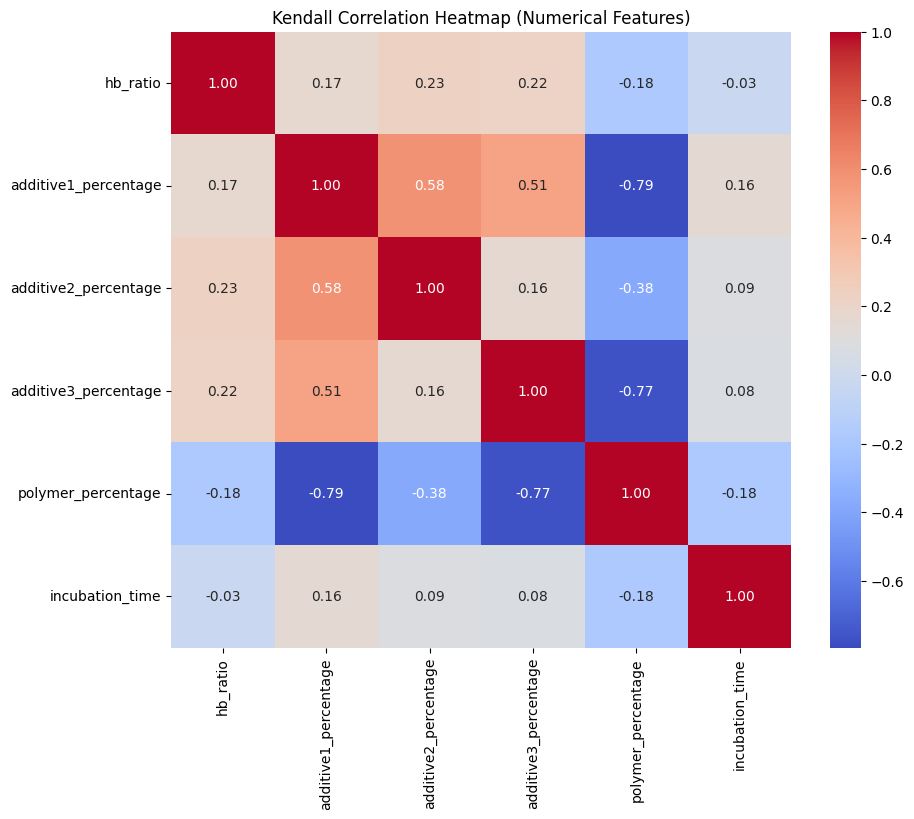

In [57]:
# Use Kendall correlation for numerical features between them
kendall_corr = X_train_clean[numerical_cols].corr(method='kendall')
plt.figure(figsize=(10, 8))
sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Kendall Correlation Heatmap (Numerical Features)')
# plt.savefig('../data/Kendall Correlation Heatmap - Cytotoxicity Model.png', dpi=600, bbox_inches='tight')

plt.show()

## Cramér's V (Cat vs Cat)

C:\Users\leoni\AppData\Local\Temp\ipykernel_7484\245906871.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()


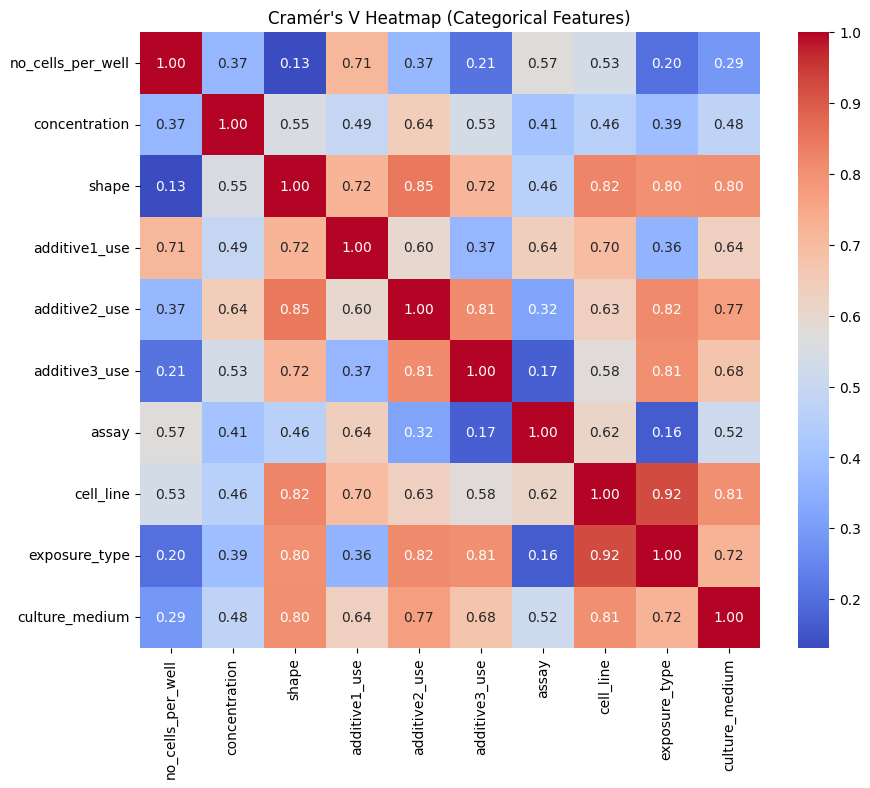

In [60]:
# Use cramer's V for categorical features between them
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))    
cat_cols = X_train_clean.select_dtypes(include=['object', 'category']).columns.tolist()
cramers_v_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols)
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(X_train_clean[col1], X_train_clean[col2])
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Cramér's V Heatmap (Categorical Features)")
plt.show()

## Drop Unnecessary Features

In [62]:
# feature_to_drop = mi_scores_series.keys()[-1] # get the feature with the lowest MI score
# X_train_clean = X_train_clean.drop(columns=feature_to_drop)
# X_test_clean  = X_test_clean.drop(columns=feature_to_drop)
# print(f"Drop feature: {feature_to_drop}") 

# Machine Learning Algorithm

In [66]:
# Recompute numerical and categorical features 
numerical_cols = X_train_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in X_train_clean.columns
                    if c not in numerical_cols and c != target]

print(f"Numerical features ({len(numerical_cols)}):")
for c in numerical_cols: print(f"  - {c}")
print(f"\nCategorical features ({len(categorical_cols)}):")
for c in categorical_cols: print(f"  - {c}")

features_num = numerical_cols
features_cat = categorical_cols

Numerical features (6):
  - hb_ratio
  - additive1_percentage
  - additive2_percentage
  - additive3_percentage
  - polymer_percentage
  - incubation_time

Categorical features (10):
  - no_cells_per_well
  - concentration
  - shape
  - additive1_use
  - additive2_use
  - additive3_use
  - assay
  - cell_line
  - exposure_type
  - culture_medium


In [68]:
# Preprocessing pipeline
def build_preprocessor(features_num, features_cat):
    """
    Returns a fresh, unfitted ColumnTransformer.
    Call this every time you need a new preprocessor instance
    """
    return ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                features_num
            ),
            (
                "cat",
                OneHotEncoder(
                    handle_unknown="ignore",   
                    sparse_output=False,
                    drop="if_binary"           
                ),
                features_cat
            ),
        ],
        remainder="drop",  # drop any column not explicitly listed
    )

## Applicability Domain 

In [71]:
# Preprocessing only for Applicability domain
pre_ad = build_preprocessor(features_num, features_cat)
 
X_train_preprocessed = pre_ad.fit_transform(X_train_clean)
X_test_preprocessed  = pre_ad.transform(X_test_clean)
 
print("\nPreprocessed shapes:")
print(f"  X_train_preprocessed: {X_train_preprocessed.shape}")
print(f"  X_test_preprocessed:  {X_test_preprocessed.shape}")


Preprocessed shapes:
  X_train_preprocessed: (123, 42)
  X_test_preprocessed:  (31, 42)


In [73]:
# Applicability Domain check

doa_methods = {
    "Leverage":    Leverage(),
    "BoundingBox": BoundingBox()
}
 
in_doa_per_method = {}
for name, method in doa_methods.items():
    method.fit(X_train_preprocessed)
    preds = method.predict(X_test_preprocessed)
    in_doa_per_method[name] = np.array([bool(p["inDoa"]) for p in preds])
 
ad_df = pd.DataFrame(in_doa_per_method, index=X_test_clean.index)
ad_df["votes_in"]  = ad_df.sum(axis=1)
ad_df["votes_out"] = len(doa_methods) - ad_df["votes_in"]
ad_df["in_domain"] = ad_df["votes_in"] >= 2  # unanimous vote (must be in-domain in both methods)
 
print("\nPer-method in-domain counts (test set):")
for name in doa_methods:
    n_in  = int(ad_df[name].sum())
    n_out = int((~ad_df[name]).sum())
    print(f"  {name:<12}  in: {n_in:>3}   out: {n_out:>3}")
 
n_total  = len(ad_df)
n_in_maj = int(ad_df["in_domain"].sum())
print(f"\nUnanimous vote (>= 2/{len(doa_methods)} in-domain):")
print(f"  Kept (in-domain):     {n_in_maj} / {n_total}")
print(f"  Excluded (out-of-AD): {n_total - n_in_maj} / {n_total}")

# Preprocessed arrays no longer needed
del X_train_preprocessed, X_test_preprocessed, pre_ad



Per-method in-domain counts (test set):
  Leverage      in:  28   out:   3
  BoundingBox   in:  31   out:   0

Unanimous vote (>= 2/2 in-domain):
  Kept (in-domain):     28 / 31
  Excluded (out-of-AD): 3 / 31


In [75]:
# AD-filtered RAW test set - used for all evaluations below
in_domain_mask  = ad_df["in_domain"].values                              
X_test_clean_ad = X_test_clean.iloc[in_domain_mask].reset_index(drop=True)  
y_test_clean_ad = y_test_clean.iloc[in_domain_mask].reset_index(drop=True) 

In [77]:
y_train_clean.value_counts()

toxicity
non-toxic    70
toxic        53
Name: count, dtype: int64

# Jacpot Deployment

In [81]:
cols_to_drop = ['polymer_percentage', 'shape', 'cell_line', 'exposure_type']

# Built Pycaret's datasets
train_data = X_train_clean.copy()
train_data[target] = y_train_clean.values

test_data_ad = X_test_clean_ad.copy()
test_data_ad[target] = y_test_clean_ad.values

train_data = train_data.drop(columns=cols_to_drop)
test_data_ad = test_data_ad.drop(columns=cols_to_drop)

print(train_data.columns.tolist())
print(test_data_ad.columns.tolist())

['hb_ratio', 'additive1_percentage', 'additive2_percentage', 'additive3_percentage', 'no_cells_per_well', 'concentration', 'incubation_time', 'additive1_use', 'additive2_use', 'additive3_use', 'assay', 'culture_medium', 'toxicity']
['hb_ratio', 'additive1_percentage', 'additive2_percentage', 'additive3_percentage', 'no_cells_per_well', 'concentration', 'incubation_time', 'additive1_use', 'additive2_use', 'additive3_use', 'assay', 'culture_medium', 'toxicity']


In [83]:
# Fix dtypes
for d in [train_data, test_data_ad]:
    string_cols = d.select_dtypes(include='string').columns
    category_cols = d.select_dtypes(include='category').columns
    d[string_cols] = d[string_cols].astype(object)
    d[category_cols] = d[category_cols].astype(object)

# Rebuild datasets
train_dataset = JaqpotTabularDataset(
    df=train_data,
    x_cols=train_data.drop(columns=[target]).columns.to_list(),
    y_cols=target,
    task="BINARY_CLASSIFICATION",
)
test_dataset = JaqpotTabularDataset(
    df=test_data_ad,
    x_cols=test_data_ad.drop(columns=[target]).columns.to_list(),
    y_cols=target,
    task="BINARY_CLASSIFICATION",
)

In [85]:
# Fix any remaining category dtype cols to object for jaqpotpy compatibility
cat_dtype_cols = train_data.select_dtypes("category").columns.tolist()
train_data[cat_dtype_cols] = train_data[cat_dtype_cols].astype(str)
test_data_ad[cat_dtype_cols] = test_data_ad[cat_dtype_cols].astype(str)

## Import model

In [87]:
string_cols = train_dataset.X.select_dtypes(include='string').columns
category_cols = train_dataset.X.select_dtypes(include='category').columns

print("string dtype columns:", string_cols.tolist())
print("category dtype columns:", category_cols.tolist())

train_dataset.X[string_cols] = train_dataset.X[string_cols].astype(object)
train_dataset.X[category_cols] = train_dataset.X[category_cols].astype(object)

print(train_dataset.X.dtypes.value_counts())

string dtype columns: []
category dtype columns: []
object     7
float64    5
Name: count, dtype: int64


In [91]:
features_num = [f for f in features_num if f not in cols_to_drop]
features_cat = [f for f in features_cat if f not in cols_to_drop]

In [93]:
import joblib
final_model = joblib.load('final_model.pkl')

jaqpot_model = SklearnModel(
    dataset=train_dataset,
    model=final_model,
    doa=[Leverage(), BoundingBox()],
    preprocess_x=build_preprocessor(features_num, features_cat)
)
jaqpot_model.random_seed = 1231
jaqpot_model.fit()
print("Jaqpot model ready")

C:\Users\leoni\anaconda3\envs\pycaret_env\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator GradientBoostingClassifier from version 1.4.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\leoni\anaconda3\envs\pycaret_env\Lib\site-packages\sklearn\ensemble\_gb.py:666: FutureWarning: The parameter `criterion` is deprecated and will be removed in 1.11. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


Goodness-of-fit metrics on training set:
{'accuracy': 0.967479674796748, 'balancedAccuracy': 0.9691374663072776, 'precision': array([0.95714286, 0.98113208]), 'recall': array([0.98529412, 0.94545455]), 'f1Score': array([0.97101449, 0.96296296]), 'jaccard': array([0.94366197, 0.92857143]), 'matthewsCorrCoef': 0.9345042210459754, 'confusionMatrix': array([[67,  3],
       [ 1, 52]], dtype=int64)}
Jaqpot model ready


In [95]:
final_model.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'friedman_mse',
 'init': None,
 'learning_rate': 0.1,
 'loss': 'log_loss',
 'max_depth': 3,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_iter_no_change': None,
 'random_state': 1231,
 'subsample': 1.0,
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': 0,
 'warm_start': False}

In [97]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [99]:
# Perform cross-validation on the training data
cv_results = jaqpot_model.cross_validate(train_dataset, n_splits=NUM_SPLITS)
cv_results

{'accuracy': 0.8538461538461538,
 'balancedAccuracy': 0.8533134920634922,
 'precision': array([0.8577381 , 0.84888889]),
 'recall': array([0.88293651, 0.84111111]),
 'f1Score': array([0.85205415, 0.82563492]),
 'jaccard': array([0.75646825, 0.71365079]),
 'matthewsCorrCoef': 0.713634641093032,
 'confusionMatrix': array([[6. , 1. ],
        [0.8, 4.5]])}

In [101]:
# Evaluate the model on the test dataset
test_results = jaqpot_model.evaluate(test_dataset)
test_results

{'accuracy': 0.9285714285714286,
 'balancedAccuracy': 0.9282051282051282,
 'precision': array([0.93333333, 0.92307692]),
 'recall': array([0.93333333, 0.92307692]),
 'f1Score': array([0.93333333, 0.92307692]),
 'jaccard': array([0.875     , 0.85714286]),
 'matthewsCorrCoef': 0.8564102564102564,
 'confusionMatrix': array([[14,  1],
        [ 1, 12]], dtype=int64)}

In [103]:
# Conduct a randomization test to assess the model's robustness
jaqpot_model.randomization_test(
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    n_iters=10,
)

{'iteration_0': {'Train': {'accuracy': 0.7967479674796748,
   'balancedAccuracy': 0.780188679245283,
   'precision': array([0.9       , 0.66037736]),
   'recall': array([0.77777778, 0.83333333]),
   'f1Score': array([0.83443709, 0.73684211]),
   'jaccard': array([0.71590909, 0.58333333]),
   'matthewsCorrCoef': 0.5851946942588246,
   'confusionMatrix': array([[63,  7],
          [18, 35]], dtype=int64)},
  'Test': {'accuracy': 0.4642857142857143,
   'balancedAccuracy': 0.458974358974359,
   'precision': array([0.53333333, 0.38461538]),
   'recall': array([0.5       , 0.41666667]),
   'f1Score': array([0.51612903, 0.4       ]),
   'jaccard': array([0.34782609, 0.25      ]),
   'matthewsCorrCoef': -0.08268982305947231,
   'confusionMatrix': array([[8, 7],
          [8, 5]], dtype=int64)}},
 'iteration_1': {'Train': {'accuracy': 0.7479674796747967,
   'balancedAccuracy': 0.7442048517520216,
   'precision': array([0.77142857, 0.71698113]),
   'recall': array([0.7826087, 0.7037037]),
   'f1

## Applicability Domain

In [105]:
doa_predictions = jaqpot_model.predict_doa(test_dataset)

summary = {}
for key in ['LEVERAGE','BOUNDING_BOX']:
    df_doa = pd.DataFrame(doa_predictions[key])
    summary[key] = {
        'n_total': len(df_doa),
        'n_in': int(df_doa['inDoa'].sum()),
        'n_out': int((~df_doa['inDoa']).sum())
    }
summary

{'LEVERAGE': {'n_total': 28, 'n_in': 28, 'n_out': 0},
 'BOUNDING_BOX': {'n_total': 28, 'n_in': 28, 'n_out': 0}}

## Confusion Matrix

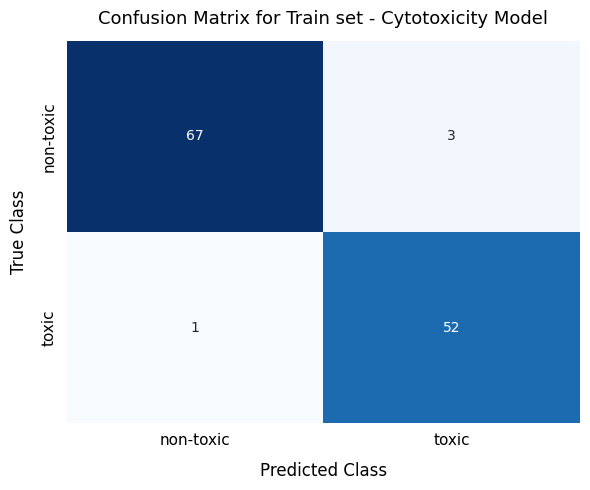

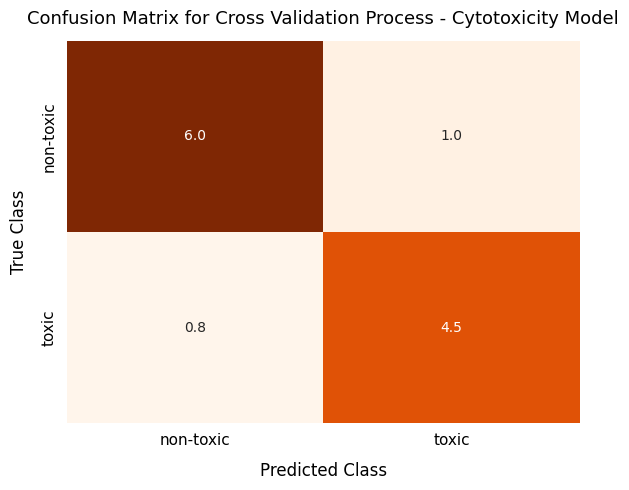

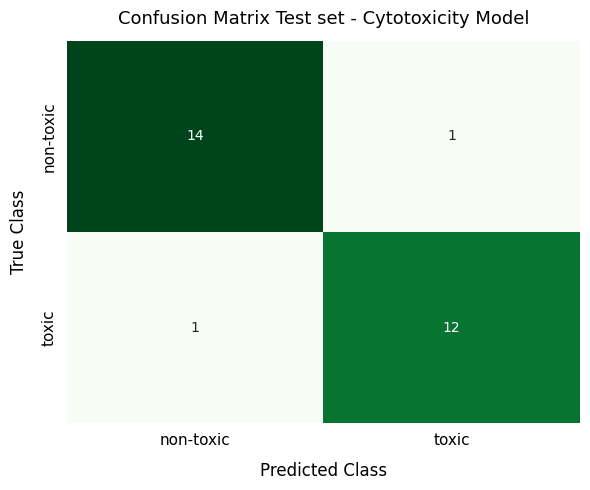

In [109]:
# Plot confusion matrix for train and test set based on the tuned model predictions
def plot_confusion_matrix(cm, title, color, fmt='d'):
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(cm, annot=True, fmt=fmt, cmap=color, cbar=False)
    
    classes = sorted(y_train_clean.unique())
    ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticklabels(classes, fontsize=11)    
    # Remove tick marks and spines
    ax.tick_params(which='both', bottom=False, left=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xlabel('Predicted Class', fontsize=12, labelpad=10)
    ax.set_ylabel('True Class', fontsize=12, labelpad=10)
    ax.set_title(title, fontsize=13, pad=12)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_").lower()}.png', dpi=600, bbox_inches='tight')
    plt.show() 
    
# Confusion matrix for train set
train_results = jaqpot_model.train_scores
cm_train = train_results['confusionMatrix']
plot_confusion_matrix(cm_train, 'Confusion Matrix for Train set - Cytotoxicity Model', 'Blues')

# Confusion matrix for cv in train set
cm_cv = cv_results['confusionMatrix']
plot_confusion_matrix(cm_cv, 'Confusion Matrix for Cross Validation Process - Cytotoxicity Model', 'Oranges', fmt='.1f')

# Confusion matrix for test set
cm_test = test_results['confusionMatrix']
plot_confusion_matrix(cm_test, 'Confusion Matrix Test set - Cytotoxicity Model', 'Greens')

## Upload Model on Jaqpot

In [111]:
# Deploy
jaqpot = Jaqpot()
jaqpot.login()
jaqpot_model.deploy_on_jaqpot(
    jaqpot=jaqpot,
    name="Cytotoxicity classification model for PHBV polymers A.N.I.P.H.",
    description="Predict cytotoxicity of PHBV polymers.",
    visibility="PUBLIC",
)

Open this URL in your browser and log in:
https://login.jaqpot.org/realms/jaqpot/protocol/openid-connect/auth?client_id=jaqpot-client&response_type=code&redirect_uri=urn:ietf:wg:oauth:2.0:oob&scope=openid email profile&state=random_state_value&nonce=


Enter the authorization code you received:  ········


  2026-07-24 22:38:38,981 - INFO - Model has been successfully uploaded. The url of the model is https://app.jaqpot.org/dashboard/models/2404


In [117]:
train_dataset.X[features_num].agg(['min', 'max'])

,hb_ratio,additive1_percentage,additive2_percentage,additive3_percentage,incubation_time
min,85.0,0.00,0.00,0.00,24.0
max,100.0,60.61,33.33,20.98,72.0
